# Hotel Review Sentiment Analysis with BERT

This notebook fine-tunes the pretrained `bert-base-uncased` model for binary sentiment classification of hotel reviews. Reviews are classified as:

- **0: Negative**
- **1: Positive**

The model is trained using 64,097 reviews and evaluated using a held-out test set of 16,025 reviews. Performance is measured using accuracy, precision, recall, F1 score, and ROC-AUC.

## 1. Load Libraries and Dataset

In [31]:
import numpy as np
import pandas as pd
import torch
import transformers
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from datasets import Dataset
from scipy.special import softmax
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

print("========== Library Versions ==========")
print("Transformers:", transformers.__version__)
print("PyTorch:", torch.__version__)

========== Library Versions ==========
Transformers: 5.12.1
PyTorch: 2.12.1


In [2]:
train_df = pd.read_csv("datasets/train_hotel_reviews.csv")
test_df = pd.read_csv("datasets/test_hotel_reviews.csv")

print("========== Dataset Shapes ==========")
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

========== Dataset Shapes ==========
Training shape: (64097, 9)
Testing shape: (16025, 9)


## 2. Dataset Validation and Label Preparation

In [3]:
print("========== Training Dataset Columns ==========")
print(train_df.columns)

print("\n========== Sample Reviews ==========")
print(train_df[["review_text", "sentiment"]].head())

print("\n========== Training Set Class Distribution ==========")
print(train_df["sentiment"].value_counts())

print("\n========== Testing Set Class Distribution ==========")
print(test_df["sentiment"].value_counts())

print("\n========== Missing Values - Training Set ==========")
print(train_df[["review_text", "sentiment"]].isnull().sum())

print("\n========== Missing Values - Testing Set ==========")
print(test_df[["review_text", "sentiment"]].isnull().sum())

========== Training Dataset Columns ==========
Index(['overall', 'value', 'service', 'location', 'rooms', 'cleanliness',
       'sleep_quality', 'review_text', 'sentiment'],
      dtype='str')

========== Sample Reviews ==========
                                         review_text  sentiment
0  “Second and Third Visits Proved Excellent” I r...          1
1  “Fantastic” We stayed in the Spa Suite for fou...          1
2  “Immaculate and beautiful” Stayed one night in...          1
3  “Very nice hotel. Great staff.” Stayed here fo...          1
4  “Very Nice Hotel, quiet, great location” This ...          1

========== Training Set Class Distribution ==========
sentiment
1    45758
0    18339
Name: count, dtype: int64

========== Testing Set Class Distribution ==========
sentiment
1    11440
0     4585
Name: count, dtype: int64

========== Missing Values - Training Set ==========
review_text    0
sentiment      0
dtype: int64

========== Missing Values - Testing Set ==========
review_t

In [4]:
# The sentiment column already contains numeric labels:
# 0 = Negative
# 1 = Positive

train_df["label"] = train_df["sentiment"].astype(int)
test_df["label"] = test_df["sentiment"].astype(int)

print("========== Sentiment to Label Verification (Training Set) ==========")
print(train_df[["sentiment", "label"]].head())

print("\n========== Training Set Label Distribution ==========")
print(train_df["label"].value_counts())

print("\n========== Testing Set Label Distribution ==========")
print(test_df["label"].value_counts())

========== Sentiment to Label Verification (Training Set) ==========
   sentiment  label
0          1      1
1          1      1
2          1      1
3          1      1
4          1      1

========== Training Set Label Distribution ==========
label
1    45758
0    18339
Name: count, dtype: int64

========== Testing Set Label Distribution ==========
label
1    11440
0     4585
Name: count, dtype: int64


## 3. Initialize the BERT Tokenizer

The `bert-base-uncased` tokenizer lowercases text and converts words into WordPiece tokens. Reviews are truncated to a maximum of 256 tokens to balance context retention, speed, and memory use.

In [5]:
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("========== Tokenizer Loaded ==========")
print("Model:", MODEL_NAME)
print("Vocabulary size:", tokenizer.vocab_size)
print("Maximum model length:", tokenizer.model_max_length)

========== Tokenizer Loaded ==========
Model: bert-base-uncased
Vocabulary size: 30522
Maximum model length: 512


In [6]:
sample_review = train_df.loc[0, "review_text"]

encoded_review = tokenizer(
    sample_review,
    truncation=True,
    max_length=256
)

print("========== Original Review ==========")
print(sample_review)

print("\n========== Tokenized Review ==========")
print(tokenizer.tokenize(sample_review)[:40])

print("\n========== Encoded Input ==========")
print("Input IDs:", encoded_review["input_ids"][:20])
print("Attention Mask:", encoded_review["attention_mask"][:20])
print("Total Tokens:", len(encoded_review["input_ids"]))

========== Original Review ==========
“Second and Third Visits Proved Excellent” I recently stayed at the Marriott at Houston's Intercontinental Airport unexpectedly on a Friday night and then I had a planned stayed two days later on Sunday.
I stayed unexpectedly on Friday night because the airport was closed due to storms. I arrived about six hours late which required me to stay overnight along with hundreds of other people. As posted earlier, there is a complimentary tram underground that links all of the terminals and the hotel. It's very easy to use and very convenient.
Given the hectic situation, the hotel did a very nice job. There were dozens of people trying to get rooms. I did not have to wait long to get checked in. My room was very clean and looked newly renovated. It was not large, but not cramped either. The bed was very comfortable. The bathroom was small but featured an oversized shower head and curved curtain rod to increase room in the shower/bathtub space. 
I did not 

## 4. Prepare and Tokenize the Dataset

Only the review text and label are retained. The pandas DataFrames are converted into Hugging Face datasets, tokenized in batches, and dynamically padded during training.

In [7]:
# Keep only the columns needed for text classification
train_bert_df = train_df[["review_text", "label"]].copy()
test_bert_df = test_df[["review_text", "label"]].copy()

# Convert pandas DataFrames into Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(
    train_bert_df,
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_bert_df,
    preserve_index=False
)

print("========== Training Dataset ==========")
print(train_dataset)

print("\n========== Testing Dataset ==========")
print(test_dataset)

========== Training Dataset ==========
Dataset({
    features: ['review_text', 'label'],
    num_rows: 64097
})

========== Testing Dataset ==========
Dataset({
    features: ['review_text', 'label'],
    num_rows: 16025
})


### Tokenize All Reviews

In [8]:
def tokenize_reviews(batch):
    return tokenizer(
        batch["review_text"],
        truncation=True,
        max_length=256
    )

tokenized_train_dataset = train_dataset.map(
    tokenize_reviews,
    batched=True
)

tokenized_test_dataset = test_dataset.map(
    tokenize_reviews,
    batched=True
)

print("========== Tokenized Training Dataset ==========")
print(tokenized_train_dataset)

print("\n========== Tokenized Testing Dataset ==========")
print(tokenized_test_dataset)

Map:   0%|          | 0/64097 [00:00<?, ? examples/s]

Map:   0%|          | 0/16025 [00:00<?, ? examples/s]

========== Tokenized Training Dataset ==========
Dataset({
    features: ['review_text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 64097
})

========== Tokenized Testing Dataset ==========
Dataset({
    features: ['review_text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 16025
})


### Create the Dynamic Padding Collator

In [9]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("========== Data Collator Created ==========")
print(data_collator)

========== Data Collator Created ==========
DataCollatorWithPadding(tokenizer=BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}), padding=True, max_length=None, pad_to_multiple_of=None, return_tensors='pt')


### Inspect One Tokenized Example

In [10]:
sample = tokenized_train_dataset[0]

print("========== Tokenized Example ==========")
print("Label:", sample["label"])
print("Number of input IDs:", len(sample["input_ids"]))
print("Number of attention-mask values:", len(sample["attention_mask"]))
print("First 20 input IDs:", sample["input_ids"][:20])

========== Tokenized Example ==========
Label: 1
Number of input IDs: 256
Number of attention-mask values: 256
First 20 input IDs: [101, 1523, 2117, 1998, 2353, 7879, 4928, 6581, 1524, 1045, 3728, 4370, 2012, 1996, 26490, 2012, 5395, 1005, 1055, 18725]


## 5. Configure the BERT Classification Model

In [11]:
# Define readable names for the two sentiment classes
id2label = {
    0: "Negative",
    1: "Positive"
}

label2id = {
    "Negative": 0,
    "Positive": 1
}

# Load bert-base-uncased with a new classification layer
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

print("========== BERT Classification Model Loaded ==========")
print("Model:", MODEL_NAME)
print("Number of labels:", model.config.num_labels)
print("Label mapping:", model.config.id2label)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


========== BERT Classification Model Loaded ==========
Model: bert-base-uncased
Number of labels: 2
Label mapping: {0: 'Negative', 1: 'Positive'}


## 6. Define Evaluation Metrics

Accuracy alone may be misleading because the dataset contains more positive than negative reviews. Therefore, evaluation also includes precision, recall, F1 score, and ROC-AUC. Precision, recall, and F1 are calculated with the positive class as the target class.

In [12]:
def compute_metrics(eval_pred):
    """
    Calculate classification metrics during model evaluation.
    """

    logits, labels = eval_pred

    # Convert model logits into predicted classes
    predictions = np.argmax(logits, axis=-1)

    # Convert logits into probabilities for ROC-AUC
    probabilities = softmax(logits, axis=1)[:, 1]

    # Calculate precision, recall, and F1 for the positive class
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)
    roc_auc = roc_auc_score(labels, probabilities)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    }


print("========== Evaluation Metrics Configured ==========")
print("Metrics: Accuracy, Precision, Recall, F1, and ROC-AUC")

========== Evaluation Metrics Configured ==========
Metrics: Accuracy, Precision, Recall, F1, and ROC-AUC


## 7. Configure the Training Environment

In [13]:
if torch.cuda.is_available():
    device_name = torch.cuda.get_device_name(0)
    device_type = "CUDA GPU"

elif torch.backends.mps.is_available():
    device_name = "Apple Silicon GPU"
    device_type = "MPS"

else:
    device_name = "CPU"
    device_type = "CPU"

print("========== Training Device ==========")
print("Device type:", device_type)
print("Device:", device_name)

========== Training Device ==========
Device type: MPS
Device: Apple Silicon GPU


In [14]:
training_args = TrainingArguments(
    output_dir="models/bert_full_checkpoints",

    # Optimization
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    warmup_steps=800,

    # Evaluation and checkpointing
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=False,
    save_total_limit=2,

    # Logging
    logging_strategy="steps",
    logging_steps=250,
    report_to="none",

    # Apple Silicon compatibility
    dataloader_pin_memory=False,

    # Reproducibility
    seed=42,
)

print("========== Training Arguments Configured ==========")
print("Epochs:", training_args.num_train_epochs)
print("Training batch size:", training_args.per_device_train_batch_size)
print("Evaluation batch size:", training_args.per_device_eval_batch_size)
print("Learning rate:", training_args.learning_rate)
print("Warmup steps:", training_args.warmup_steps)

========== Training Arguments Configured ==========
Epochs: 2
Training batch size: 8
Evaluation batch size: 8
Learning rate: 2e-05
Warmup steps: 800


## 8. Validate the Training Pipeline on a Small Sample

A small subset is used only to verify that tokenization, batching, training, evaluation, and Apple Silicon acceleration operate correctly. These results are not used as the final estimate of model performance.

In [15]:
small_train_dataset = (
    tokenized_train_dataset
    .shuffle(seed=42)
    .select(range(1000))
)

small_test_dataset = (
    tokenized_test_dataset
    .shuffle(seed=42)
    .select(range(250))
)

print("========== Small Validation Datasets Created ==========")
print("Training examples:", len(small_train_dataset))
print("Evaluation examples:", len(small_test_dataset))

========== Small Validation Datasets Created ==========
Training examples: 1000
Evaluation examples: 250


In [16]:
test_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

test_trainer = Trainer(
    model=test_model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_test_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("========== Small Training Test Ready ==========")
print("Training examples:", len(small_train_dataset))
print("Evaluation examples:", len(small_test_dataset))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


========== Small Training Test Ready ==========
Training examples: 1000
Evaluation examples: 250


In [17]:
# This test modifies only test_model, not the model used for final training.
test_train_result = test_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,No log,0.586553,0.724000,0.725806,0.994475,0.839161,0.717031
2,0.596681,0.482985,0.756000,0.947761,0.701657,0.806349,0.894227


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [18]:
test_metrics = test_trainer.evaluate()

print("========== Small Test Evaluation Results ==========")

for metric_name, metric_value in test_metrics.items():
    if isinstance(metric_value, float):
        print(f"{metric_name}: {metric_value:.4f}")
    else:
        print(f"{metric_name}: {metric_value}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Roc Auc
0.596681,0.482985,2,0.756000,0.947761,0.701657,0.806349,0.894227


========== Small Test Evaluation Results ==========
eval_loss: 0.4830
eval_accuracy: 0.7560
eval_precision: 0.9478
eval_recall: 0.7017
eval_f1: 0.8063
eval_roc_auc: 0.8942


## 9. Fine-Tune BERT on the Full Dataset

After validating the pipeline, a fresh copy of `bert-base-uncased` is fine-tuned on the complete training set. A fresh model prevents the small-sample validation run from influencing the final model weights.

In [19]:
full_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

trainer = Trainer(
    model=full_model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("========== Full Trainer Ready ==========")
print("Training examples:", len(tokenized_train_dataset))
print("Evaluation examples:", len(tokenized_test_dataset))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


========== Full Trainer Ready ==========
Training examples: 64097
Evaluation examples: 16025


In [20]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.287680,0.285859,0.896287,0.909945,0.948601,0.928871,0.952946
2,0.230436,0.342013,0.899782,0.921192,0.940035,0.930518,0.956517


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 10. Final Model Evaluation

In [21]:
final_metrics = trainer.evaluate()

print("========== Final BERT Evaluation Results ==========")

for metric_name, metric_value in final_metrics.items():
    if isinstance(metric_value, float):
        print(f"{metric_name}: {metric_value:.4f}")
    else:
        print(f"{metric_name}: {metric_value}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Roc Auc
0.230436,0.342013,2,0.899782,0.921192,0.940035,0.930518,0.956517


========== Final BERT Evaluation Results ==========
eval_loss: 0.3420
eval_accuracy: 0.8998
eval_precision: 0.9212
eval_recall: 0.9400
eval_f1: 0.9305
eval_roc_auc: 0.9565


In [25]:
# Generate predictions on the held-out test dataset
predictions = trainer.predict(tokenized_test_dataset)

# Predicted class labels
y_pred = np.argmax(predictions.predictions, axis=1)

# True class labels
y_true = predictions.label_ids

print("========== Predictions Generated ==========")

print("Number of test samples:", len(y_true))

========== Predictions Generated ==========
Number of test samples: 16025


========== Confusion Matrix ==========
[[ 3665   920]
 [  686 10754]]


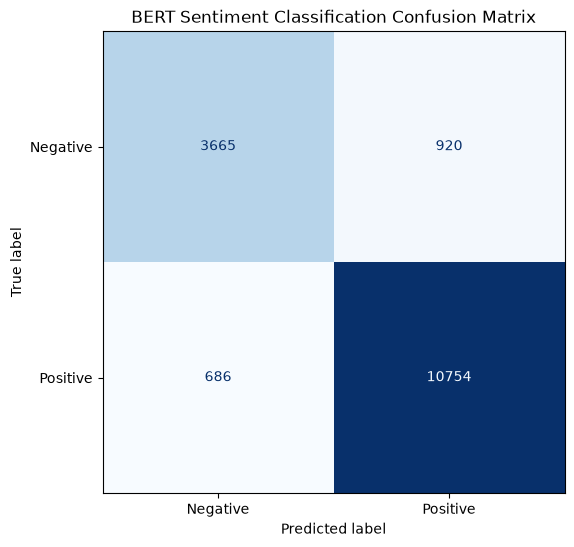

In [ ]:
# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("========== Confusion Matrix ==========")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(
    cmap="Blues",
    colorbar=False,
    ax=ax
)

plt.title("BERT Sentiment Classification Confusion Matrix")
plt.show()

In [ ]:
print("========== Classification Report ==========")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

========== Classification Report ==========
              precision    recall  f1-score   support

    Negative       0.84      0.80      0.82      4585
    Positive       0.92      0.94      0.93     11440

    accuracy                           0.90     16025
   macro avg       0.88      0.87      0.88     16025
weighted avg       0.90      0.90      0.90     16025



In [30]:
# Create a copy of the test dataframe
results_df = test_df.copy().reset_index(drop=True)

# Add actual and predicted labels
results_df["Actual"] = y_true
results_df["Predicted"] = y_pred

# Keep only incorrect predictions
misclassified = results_df[
    results_df["Actual"] != results_df["Predicted"]
]

print("========== Misclassified Reviews ==========")
print("Total Misclassified Reviews:", len(misclassified))

# Display the first 10 errors
misclassified[
    ["review_text", "Actual", "Predicted"]
].head(10)

========== Misclassified Reviews ==========
Total Misclassified Reviews: 1606


,review_text,Actual,Predicted
22,“Good value nice rooms however staff not so gr...,1,0
25,"“nice stay, nice rooms” Stayed here in May 200...",0,1
39,“Just a layover” I had a 8 hour lay over in PH...,1,0
41,“Mostly hits but some misses” You know the hot...,0,1
45,“Bargain price for a great room in NYC” We hav...,0,1
59,“Good Business Hotel” The property is good for...,0,1
78,“シカゴ一” 「シカゴ一」といっても、客室数がですが。。流石に世界屈指のハイアットグループの...,0,1
85,“Expensive fun” SPG knows how to make a hotel ...,0,1
92,“Not a 5 Star Property” I thought the site of ...,1,0
113,“Not What We Expected” We booked a one night s...,1,0


## 11. Save the Fine-Tuned Model

In [32]:
SAVED_MODEL_PATH = "models/bert_hotel_sentiment"

trainer.save_model(SAVED_MODEL_PATH)
tokenizer.save_pretrained(SAVED_MODEL_PATH)

print("Fine-tuned BERT model and tokenizer saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned BERT model and tokenizer saved successfully.


## 12. Verify the Saved Model

In [33]:
saved_tokenizer = AutoTokenizer.from_pretrained(SAVED_MODEL_PATH)
saved_model = AutoModelForSequenceClassification.from_pretrained(
    SAVED_MODEL_PATH
)

print("========== Saved Model Verification ==========")
print("Model loaded successfully.")
print("Number of labels:", saved_model.config.num_labels)
print("Label mapping:", saved_model.config.id2label)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

========== Saved Model Verification ==========
Model loaded successfully.
Number of labels: 2
Label mapping: {0: 'Negative', 1: 'Positive'}


## 13. Test the Saved Model on Unseen Reviews

In [24]:
sample_reviews = [
    "The hotel was beautiful, clean, and the staff were extremely helpful.",
    "The room was dirty, noisy, and the customer service was terrible.",
]

inputs = saved_tokenizer(
    sample_reviews,
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt",
)

saved_model.eval()

with torch.no_grad():
    outputs = saved_model(**inputs)

probabilities = torch.softmax(outputs.logits, dim=1)
predictions = torch.argmax(probabilities, dim=1)

print("========== Sample Predictions ==========")

for review, prediction, probability in zip(
    sample_reviews,
    predictions,
    probabilities,
):
    predicted_label = saved_model.config.id2label[prediction.item()]
    confidence = probability[prediction].item()

    print("\nReview:", review)
    print("Prediction:", predicted_label)
    print(f"Confidence: {confidence:.4f}")

========== Sample Predictions ==========

Review: The hotel was beautiful, clean, and the staff were extremely helpful.
Prediction: Positive
Confidence: 0.9991

Review: The room was dirty, noisy, and the customer service was terrible.
Prediction: Negative
Confidence: 0.9991


## 14. Results and Conclusions

The completed full-data run produced the following held-out test performance:

- **Accuracy:** 0.8995
- **Precision:** 0.9187
- **Recall:** 0.9426
- **F1 score:** 0.9305
- **ROC-AUC:** 0.9568

The fine-tuned BERT model demonstrated strong discrimination between positive and negative hotel reviews. The second epoch improved accuracy, precision, F1 score, and ROC-AUC, although validation loss increased from 0.2761 to 0.3072. This may indicate the beginning of overfitting or increased confidence on a small number of incorrect predictions.

The model and tokenizer were successfully saved and reloaded. Predictions on new positive and negative review examples confirmed that the saved model can be used for inference without retraining.